# Maze Escape Training — v3 stable 16×16 full-map

## Key fixes vs v2
| Problem | Fix |
|---|---|
| State = raw 1024-cell grid → network too small to learn | **CNN encoder** + full 16×16 one-hot map |
| `max_steps=250` too short for 16×16 maze | Raised to **500** |
| Single-episode updates → huge variance | **Mini-batch of 8 rollouts** per update |
| No bootstrap for non-terminal last state | `next_value` added to `compute_returns` |
| Entropy collapses to ~0 by ep 100 | Entropy coef **0.05**, with slow annealing |
| LR 1e-3 → exploding gradients (628!) | LR **3e-4** + cosine scheduler |
| Single static map → memorisation | `refresh_map_every_reset=True` from ep 1 |
| Curriculum switch at 60% too late | Switch at **40%**, also raises `max_steps` |
| `state_dim` hardcoded wrong | Computed dynamically from `env.reset()` |

Additional tuning in this v2 notebook: stronger progress shaping toward the exit, larger terminal reward, lighter wall penalty, and a lower entropy schedule to reduce hesitation once the agent starts finding successful paths.

In [ ]:
import os, math, random
from collections import deque

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical


In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("[INFO] device =", device)


[INFO] device = cuda


## Environment constants

In [ ]:
GRID_SIZE  = 16
N_ACTIONS  = 4
# Full-map observation: we keep the whole 16×16 grid instead of a local 7×7 crop.
FULL_MAP_OBS = True

CELL_FREE   = 0
CELL_WALL   = 1
CELL_TRAP   = 2
CELL_EXIT   = 3
CELL_PLAYER = 4
CELL_COIN   = 5
CELL_ENEMY  = 6
N_CELL_TYPES = 7

R_EXIT  =  500.0
R_TRAP  =  -25.0
R_STEP  =   -0.05  # keep exploration affordable while still encouraging progress
R_WALL  =   -0.5   # mild wall penalty; action masking already filters most invalid moves
R_COIN  =    5.0
R_DEATH =  -30.0

CUSTOM_MAP = None


## Map generation (adapted for 16×16)

In [ ]:
def _neighbors4(r, c):
    for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
        nr, nc = r+dr, c+dc
        if 0 <= nr < GRID_SIZE and 0 <= nc < GRID_SIZE:
            yield nr, nc

def _carve_path(grid, r, c, rng):
    dirs = [(0,2),(0,-2),(2,0),(-2,0)]
    rng.shuffle(dirs)
    for dr, dc in dirs:
        nr, nc = r+dr, c+dc
        if 1 <= nr < GRID_SIZE-1 and 1 <= nc < GRID_SIZE-1 and grid[nr, nc] == CELL_WALL:
            grid[r + dr//2, c + dc//2] = CELL_FREE
            grid[nr, nc] = CELL_FREE
            _carve_path(grid, nr, nc, rng)

def _shortest_path(grid, start, goal):
    from collections import deque
    walkable = {CELL_FREE, CELL_EXIT, CELL_COIN}
    q = deque([start])
    parent = {start: None}
    while q:
        cur = q.popleft()
        if cur == goal:
            break
        for nxt in _neighbors4(*cur):
            if nxt in parent:
                continue
            if grid[nxt] not in walkable:
                continue
            parent[nxt] = cur
            q.append(nxt)
    if goal not in parent:
        return None
    path, cur = [], goal
    while cur is not None:
        path.append(cur)
        cur = parent[cur]
    path.reverse()
    return path

def _safe_buffer(center, radius=2):
    r0, c0 = center
    return {
        (r, c)
        for r in range(max(0, r0-radius), min(GRID_SIZE, r0+radius+1))
        for c in range(max(0, c0-radius), min(GRID_SIZE, c0+radius+1))
    }

def _enemy_circuit_candidates(r, c):
    return [
        [(r,c),(r,c+1),(r+1,c+1),(r+1,c)],
        [(r,c),(r,c-1),(r+1,c-1),(r+1,c)],
        [(r,c),(r-1,c),(r-1,c+1),(r,c+1)],
        [(r,c),(r,c+1),(r,c+2),(r,c+3)],
        [(r,c),(r+1,c),(r+2,c),(r+3,c)],
    ]

def _can_place_enemy(grid, r, c, reserved):
    for circuit in _enemy_circuit_candidates(r, c):
        ok = True
        for pr, pc in circuit:
            if not (0 <= pr < GRID_SIZE and 0 <= pc < GRID_SIZE):
                ok = False
                break
            if grid[pr, pc] != CELL_FREE or (pr, pc) in reserved:
                ok = False
                break
        if ok:
            return True
    return False

def _clear_start_and_goal_areas(grid):
    # Keep the corner spawn and the exit corner open regardless of grid size.
    start_cells = [(r, c) for r in range(0, min(2, GRID_SIZE)) for c in range(0, min(2, GRID_SIZE))]
    goal_cells = [
        (r, c)
        for r in range(max(0, GRID_SIZE - 3), GRID_SIZE)
        for c in range(max(0, GRID_SIZE - 3), GRID_SIZE)
    ]
    for cell in start_cells + goal_cells:
        grid[cell] = CELL_FREE
    grid[GRID_SIZE - 1, GRID_SIZE - 1] = CELL_EXIT

def _small_map_cfg(difficulty):
    # Lighter densities for 16x16 so the maze stays learnable.
    return {
        "easy":   dict(traps=3,  coins=8, enemies=0),
        "medium": dict(traps=6,  coins=6, enemies=1),
        "hard":   dict(traps=10, coins=4, enemies=2),
    }[difficulty]

def _default_cfg(difficulty):
    return {
        "easy":   dict(traps=10, coins=20, enemies=3),
        "medium": dict(traps=20, coins=15, enemies=6),
        "hard":   dict(traps=35, coins=10, enemies=10),
    }[difficulty]

def generate_map(difficulty="easy", seed=None, training_mode="normal"):
    if CUSTOM_MAP is not None:
        arr = np.array(CUSTOM_MAP, dtype=np.int64)
        assert arr.shape == (GRID_SIZE, GRID_SIZE)
        return arr

    rng = random.Random(seed)
    grid = np.full((GRID_SIZE, GRID_SIZE), CELL_WALL, dtype=np.int64)

    start_inner = (1, 1)
    grid[start_inner] = CELL_FREE
    _carve_path(grid, *start_inner, rng)

    _clear_start_and_goal_areas(grid)

    start, goal = (0, 0), (GRID_SIZE - 1, GRID_SIZE - 1)
    path = _shortest_path(grid, start, goal)
    if not path:
        raise RuntimeError("Cannot generate valid map.")

    base_cfg = _small_map_cfg(difficulty) if GRID_SIZE <= 16 else _default_cfg(difficulty)

    cfg = (
        dict(
            traps=max(0, base_cfg["traps"] // 4),
            coins=base_cfg["coins"],
            enemies=0,
        )
        if training_mode == "learn"
        else base_cfg
    )

    reserved_safe = set(path) | _safe_buffer(start, 2) | _safe_buffer(goal, 2)
    free_cells = [
        (r, c) for r in range(GRID_SIZE) for c in range(GRID_SIZE)
        if grid[r, c] == CELL_FREE and (r, c) not in {(0, 0), goal}
    ]
    rng.shuffle(free_cells)

    coin_candidates = [cell for cell in free_cells if cell not in _safe_buffer(start, 1)]
    rng.shuffle(coin_candidates)
    for r, c in coin_candidates[:cfg["coins"]]:
        if grid[r, c] == CELL_FREE:
            grid[r, c] = CELL_COIN

    trap_candidates = [
        cell for cell in free_cells
        if cell not in reserved_safe and grid[cell[0], cell[1]] == CELL_FREE
    ]
    rng.shuffle(trap_candidates)
    for r, c in trap_candidates[:cfg["traps"]]:
        grid[r, c] = CELL_TRAP

    enemy_candidates = [
        cell for cell in free_cells
        if cell not in reserved_safe and grid[cell[0], cell[1]] == CELL_FREE
    ]
    rng.shuffle(enemy_candidates)
    enemies_placed = 0
    for r, c in enemy_candidates:
        if enemies_placed >= cfg["enemies"]:
            break
        if _can_place_enemy(grid, r, c, reserved_safe):
            grid[r, c] = CELL_ENEMY
            enemies_placed += 1

    return grid

## Enemy class (unchanged)

In [ ]:
class Enemy:
    def __init__(self, start_r, start_c, grid):
        self.r = start_r
        self.c = start_c
        self.circuit = self._build_circuit(start_r, start_c, grid)
        self.idx = 0

    def _build_circuit(self, r, c, grid):
        candidates = [
            [(r,c),(r,c+1),(r+1,c+1),(r+1,c)],
            [(r,c),(r,c-1),(r+1,c-1),(r+1,c)],
            [(r,c),(r-1,c),(r-1,c+1),(r,c+1)],
            [(r,c),(r,c+1),(r,c+2),(r,c+3)],
            [(r,c),(r+1,c),(r+2,c),(r+3,c)],
        ]
        for circuit in candidates:
            if all(
                0 <= pr < GRID_SIZE and 0 <= pc < GRID_SIZE
                and grid[pr,pc] in (CELL_FREE, CELL_ENEMY)
                for pr,pc in circuit
            ):
                return circuit
        return [(r,c)]*4

    def move(self):
        self.idx = (self.idx+1) % len(self.circuit)
        self.r, self.c = self.circuit[self.idx]

    @property
    def pos(self):
        return (self.r, self.c)


## MazeEscape Environment

**FIX 1**: State now returns a *full 16×16 one-hot map* around the player  
plus a compact global vector — so the agent sees the whole maze at every step.

**FIX 2**: `max_steps` default raised to 500 (a 16×16 maze needs ~62 optimal steps;  
exploration needs 4–8× that budget).

**FIX 3**: `refresh_map_every_reset=True` by default so the agent learns to generalise,  
not memorise one layout.

In [ ]:

class MazeEscape:
    """
    State vector layout
    -------------------
    [0 : N_CELL_TYPES * GRID_SIZE * GRID_SIZE]  one-hot full map
    [+2]  normalised player (row, col)
    [+2]  normalised exit   (row, col)
    [+1]  normalised distance to exit
    [+1]  steps remaining (fraction)
    [+1]  coins collected fraction

    For GRID_SIZE=16 and N_CELL_TYPES=7:
    7 * 16 * 16 + 7 = 1799 floats
    """

    def __init__(
        self,
        difficulty="easy",
        max_steps=200,
        start_pos=(0, 0),
        seed=None,
        training_mode="normal",
        refresh_map_every_reset=True,
    ):
        self.difficulty = difficulty
        self.max_steps  = max_steps
        self.start_pos  = start_pos
        self.grid_size  = GRID_SIZE
        self.n_actions  = N_ACTIONS
        self.seed       = seed
        self.training_mode = training_mode
        self.refresh_map_every_reset = refresh_map_every_reset
        self.reset_count = 0

        self.base_grid = generate_map(difficulty, seed=seed, training_mode=training_mode)
        self._init_enemies()
        self.max_coins = int(np.sum(self.base_grid == CELL_COIN))

        self._compute_state_dim()
        self.reset()

    def _compute_state_dim(self):
        self.pos   = list(self.start_pos)
        self.steps = 0
        self.coins_collected = 0
        self.alive = True
        self.grid  = self.base_grid.copy()
        s = self._get_state()
        self.state_dim = len(s)

    def _init_enemies(self):
        spawns = [
            (r, c) for r in range(GRID_SIZE) for c in range(GRID_SIZE)
            if self.base_grid[r, c] == CELL_ENEMY
        ]
        self.enemies = [Enemy(r, c, self.base_grid) for r, c in spawns]

    def _distance_to_exit(self, pos):
        return abs((GRID_SIZE - 1) - pos[0]) + abs((GRID_SIZE - 1) - pos[1])

    def valid_action_mask(self):
        """1.0 for valid moves, 0.0 for invalid moves (wall or out-of-bounds)."""
        deltas = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}
        mask = np.ones(self.n_actions, dtype=np.float32)
        for a, (dr, dc) in deltas.items():
            nr, nc = self.pos[0] + dr, self.pos[1] + dc
            if not (0 <= nr < self.grid_size and 0 <= nc < self.grid_size):
                mask[a] = 0.0
            elif self.grid[nr, nc] == CELL_WALL:
                mask[a] = 0.0
        if mask.sum() == 0:
            mask[:] = 1.0
        return mask

    def reset(self):
        if self.refresh_map_every_reset and self.seed is not None:
            self.reset_count += 1
            self.base_grid = generate_map(
                self.difficulty,
                seed=self.seed + self.reset_count,
                training_mode=self.training_mode,
            )
            self._init_enemies()
            self.max_coins = int(np.sum(self.base_grid == CELL_COIN))

        self.grid  = self.base_grid.copy()
        self.pos   = list(self.start_pos)
        self.steps = 0
        self.done  = False
        self.total_reward   = 0.0
        self.coins_collected = 0
        self.alive = True
        self.prev_dist = self._distance_to_exit(self.pos)

        for e in self.enemies:
            e.idx = 0
            e.r, e.c = e.circuit[0]

        return self._get_state()

    def step(self, action):
        assert not self.done
        deltas = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}
        dr, dc = deltas[action]
        nr, nc = self.pos[0] + dr, self.pos[1] + dc

        old_dist = self._distance_to_exit(self.pos)

        out_of_bounds = not (0 <= nr < self.grid_size and 0 <= nc < self.grid_size)
        hits_wall = (not out_of_bounds) and (self.grid[nr, nc] == CELL_WALL)

        if out_of_bounds or hits_wall:
            reward = R_WALL
        else:
            self.pos = [nr, nc]
            cell = self.grid[nr, nc]
            if cell == CELL_EXIT:
                reward = R_EXIT
                self.done = True
            elif cell == CELL_TRAP:
                reward = R_TRAP
                self.done = True
                self.alive = False
            elif cell == CELL_COIN:
                reward = R_COIN
                self.grid[nr, nc] = CELL_FREE
                self.coins_collected += 1
            else:
                reward = R_STEP

        self.steps += 1

        if not self.done:
            for e in self.enemies:
                e.move()
                if tuple(self.pos) == e.pos:
                    reward += R_DEATH
                    self.done = True
                    self.alive = False
                    break

        new_dist = self._distance_to_exit(self.pos)
        # Moderate shaping: keep the directional signal, but avoid overdriving the critic
        reward += 1.0 * (old_dist - new_dist)

        if self.steps >= self.max_steps:
            self.done = True
            reward -= 10.0

        self.prev_dist = new_dist
        self.total_reward += reward

        info = {
            "steps": self.steps,
            "pos": tuple(self.pos),
            "coins": self.coins_collected,
            "alive": self.alive,
            "distance_to_exit": new_dist,
            "reached_exit": int(
                self.alive and self.pos[0] == GRID_SIZE - 1 and self.pos[1] == GRID_SIZE - 1
            ),
        }
        return self._get_state(), reward, self.done, info

    def _get_state(self):
        grid_view = self.grid.copy().astype(np.int64)

        # Overlay dynamic entities so the network sees the real current map.
        for e in self.enemies:
            er, ec = e.pos
            if 0 <= er < GRID_SIZE and 0 <= ec < GRID_SIZE:
                grid_view[er, ec] = CELL_ENEMY

        pr, pc = self.pos
        grid_view[pr, pc] = CELL_PLAYER

        # One-hot full map: [N_CELL_TYPES, GRID_SIZE, GRID_SIZE]
        assert grid_view.min() >= 0 and grid_view.max() < N_CELL_TYPES
        one_hot = np.eye(N_CELL_TYPES, dtype=np.float32)[grid_view]
        one_hot = np.transpose(one_hot, (2, 0, 1))  # channels first
        map_flat = one_hot.reshape(-1)

        global_feats = np.array([
            pr / (GRID_SIZE - 1 + 1e-8),
            pc / (GRID_SIZE - 1 + 1e-8),
            (GRID_SIZE - 1) / (GRID_SIZE - 1 + 1e-8),
            (GRID_SIZE - 1) / (GRID_SIZE - 1 + 1e-8),
            self._distance_to_exit(self.pos) / (2 * (GRID_SIZE - 1) + 1e-8),
            1.0 - (self.steps / max(1, self.max_steps)),
            self.coins_collected / max(1, self.max_coins),
        ], dtype=np.float32)

        return np.concatenate([map_flat, global_feats], axis=0)


## Network — CNN + MLP Actor-Critic

**FIX**: A small CNN processes the local 7×7 spatial input,  
giving the model spatial inductive bias without requiring it to  
memorise which of 1024 cells is which.

In [ ]:

class ActorCriticNet(nn.Module):
    """
    Input layout: [N_CELL_TYPES * GRID_SIZE * GRID_SIZE | 7 global floats]
    """

    def __init__(self, state_dim, n_actions, hidden_sizes=(256, 128)):
        super().__init__()

        cnn_input_size = N_CELL_TYPES * GRID_SIZE * GRID_SIZE
        global_size = state_dim - cnn_input_size
        self._cnn_input_size = cnn_input_size

        self.cnn = nn.Sequential(
            nn.Conv2d(N_CELL_TYPES, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Flatten(),
        )

        cnn_out = 64 * GRID_SIZE * GRID_SIZE

        in_dim = cnn_out + global_size
        layers = []
        for h in hidden_sizes:
            layers += [nn.Linear(in_dim, h), nn.LayerNorm(h), nn.ReLU()]
            in_dim = h

        self.backbone = nn.Sequential(*layers)
        self.policy_head = nn.Linear(in_dim, n_actions)
        self.value_head = nn.Linear(in_dim, 1)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Linear, nn.Conv2d)):
                nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
                nn.init.zeros_(m.bias)
        nn.init.orthogonal_(self.policy_head.weight, gain=0.01)

    def _split(self, x):
        cnn_part = x[:, :self._cnn_input_size].view(-1, N_CELL_TYPES, GRID_SIZE, GRID_SIZE)
        global_part = x[:, self._cnn_input_size:]
        return cnn_part, global_part

    def _apply_action_mask(self, logits, action_mask=None):
        if action_mask is None:
            return logits
        mask = torch.tensor(action_mask, dtype=torch.float32, device=logits.device).unsqueeze(0)
        return logits.masked_fill(mask <= 0, -1e9)

    def forward(self, x):
        cnn_part, global_part = self._split(x)
        z = torch.cat([self.cnn(cnn_part), global_part], dim=-1)
        z = self.backbone(z)
        return self.policy_head(z), self.value_head(z).squeeze(-1)

    def act(self, state_np, action_mask=None):
        self.train()
        x = torch.tensor(state_np, dtype=torch.float32, device=device).unsqueeze(0)
        logits, value = self.forward(x)
        logits = self._apply_action_mask(logits, action_mask)
        dist = Categorical(logits=logits)
        action = dist.sample()
        return (
            action.item(),
            dist.log_prob(action).squeeze(0),
            value.squeeze(0),
            dist.entropy().squeeze(0),
        )

    @torch.no_grad()
    def greedy_action(self, state_np, action_mask=None):
        self.eval()
        x = torch.tensor(state_np, dtype=torch.float32, device=device).unsqueeze(0)
        logits, _ = self.forward(x)
        logits = self._apply_action_mask(logits, action_mask)
        return torch.argmax(logits, dim=-1).item()

    @torch.no_grad()
    def sample_action(self, state_np, action_mask=None):
        self.eval()
        x = torch.tensor(state_np, dtype=torch.float32, device=device).unsqueeze(0)
        logits, _ = self.forward(x)
        logits = self._apply_action_mask(logits, action_mask)
        dist = Categorical(logits=logits)
        return dist.sample().item()


## Training utilities

**FIX 4**: `compute_returns` now accepts `next_value` for correct bootstrapping  
on non-terminal episode ends (timeout).

**FIX 5**: `actor_critic_update` processes a **batch of 8 rollouts** per step,  
dramatically reducing variance.

**FIX 6**: Entropy coefficient starts at 0.05 and decays slowly.

In [ ]:

def rollout_episode(env, model):
    state = env.reset()
    log_probs, values, rewards, entropies = [], [], [], []

    while not env.done:
        action_mask = env.valid_action_mask()
        action, lp, v, ent = model.act(state, action_mask=action_mask)
        next_state, reward, done, info = env.step(action)
        log_probs.append(lp)
        values.append(v)
        rewards.append(float(reward))
        entropies.append(ent)
        state = next_state

    if env.alive and not (env.pos[0] == GRID_SIZE - 1 and env.pos[1] == GRID_SIZE - 1):
        x = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        with torch.no_grad():
            _, next_val = model.forward(x)
        next_value = next_val.squeeze().item()
    else:
        next_value = 0.0

    return {
        "log_probs": log_probs,
        "values": values,
        "rewards": rewards,
        "entropies": entropies,
        "next_value": next_value,
        "total_reward": env.total_reward,
        "steps": env.steps,
        "success": int(env.alive and env.pos[0] == GRID_SIZE - 1 and env.pos[1] == GRID_SIZE - 1),
    }


def compute_returns(rewards, next_value=0.0, gamma=0.99):
    returns = []
    G = next_value
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    return torch.tensor(returns, dtype=torch.float32, device=device)


def actor_critic_update(model, optimizer, batches, gamma=0.99,
                        value_coef=0.5, entropy_coef=0.05, max_grad_norm=1.0):
    all_lp, all_val, all_ret, all_ent = [], [], [], []

    for b in batches:
        ret = compute_returns(b["rewards"], next_value=b["next_value"], gamma=gamma)
        all_lp.extend(b["log_probs"])
        all_val.extend(b["values"])
        all_ret.append(ret)
        all_ent.extend(b["entropies"])

    returns    = torch.cat(all_ret)
    values     = torch.stack(all_val)
    log_probs  = torch.stack(all_lp)
    entropies  = torch.stack(all_ent)

    # Light normalization/clipping keeps the critic from exploding on rare high-return batches.
    returns = (returns - returns.mean()) / (returns.std() + 1e-8)
    returns = torch.clamp(returns, -5.0, 5.0)

    advantages = returns - values.detach()
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
    advantages = torch.clamp(advantages, -5.0, 5.0)

    policy_loss = -(log_probs * advantages).mean()
    value_loss  = F.smooth_l1_loss(values, returns)
    entropy_bonus = entropies.mean()

    loss = policy_loss + value_coef * value_loss - entropy_coef * entropy_bonus

    optimizer.zero_grad()
    loss.backward()
    grad_norm = float(torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_grad_norm))
    optimizer.step()

    return {
        "loss": float(loss.item()),
        "policy_loss": float(policy_loss.item()),
        "value_loss": float(value_loss.item()),
        "entropy": float(entropy_bonus.item()),
        "grad_norm": grad_norm,
    }


@torch.no_grad()
def evaluate_policy(model, difficulty="easy", max_steps=200, episodes=10,
                    training_mode="normal", strategy="greedy"):
    model.eval()
    rewards, successes = [], []
    for i in range(episodes):
        env = MazeEscape(
            difficulty=difficulty,
            max_steps=max_steps,
            seed=SEED + 10_000 + i,
            training_mode=training_mode,
            refresh_map_every_reset=False,
        )
        state = env.reset()
        while not env.done:
            action_mask = env.valid_action_mask()
            if strategy == "sample":
                action = model.sample_action(state, action_mask=action_mask)
            else:
                action = model.greedy_action(state, action_mask=action_mask)
            state, _, _, _ = env.step(action)
        rewards.append(env.total_reward)
        successes.append(int(env.alive and env.pos[0] == GRID_SIZE - 1 and env.pos[1] == GRID_SIZE - 1))
    model.train()
    return float(np.mean(rewards)), float(np.mean(successes) * 100.0)


## Training loop

Key changes:
- **LR = 3e-4** (down from 1e-3) + cosine schedule
- **Batch size = 8** rollouts per update
- **Entropy coef** decays from 0.05 → 0.01
- **Curriculum switch at 40%** (earlier exposure to full difficulty)
- **`max_steps` grows** with curriculum stage

In [ ]:

def train_actor_critic(
    difficulty="easy",
    n_episodes=5000,
    max_steps=500,
    gamma=0.99,
    lr=1e-4,
    hidden=(256, 256),
    batch_size=8,
    entropy_start=0.02,
    entropy_end=0.002,
    training_mode_start="normal",
    switch_to_normal_at=None,
    log_every=100,
    eval_every=500,
    save_path="maze_policy_v3_stable_16x16_fullmap.pth",
):
    probe = MazeEscape(
        difficulty=difficulty,
        max_steps=max_steps,
        seed=SEED,
        training_mode=training_mode_start,
        refresh_map_every_reset=True,
    )
    state_dim = probe.state_dim
    n_actions = probe.n_actions
    del probe

    def make_env(training_mode, steps, env_idx):
        return MazeEscape(
            difficulty=difficulty,
            max_steps=steps,
            seed=SEED + 1000 * env_idx,
            training_mode=training_mode,
            refresh_map_every_reset=True,
        )

    model = ActorCriticNet(state_dim, n_actions, hidden_sizes=hidden).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, eps=1e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_episodes, eta_min=lr / 10)

    rewards_hist, success_hist, losses_hist = [], [], []
    recent_rewards = deque(maxlen=100)
    recent_success = deque(maxlen=100)

    training_mode = training_mode_start
    current_steps = max_steps

    print("=" * 80)
    print(f"Actor-Critic v3 stable 16x16 full-map | difficulty={difficulty} | episodes={n_episodes} | device={device}")
    print(f"state_dim={state_dim} | batch_size={batch_size} | lr={lr} | mode={training_mode}")
    print("=" * 80)

    envs = [make_env(training_mode, current_steps, i) for i in range(batch_size)]
    ep = 0

    while ep < n_episodes:
        if switch_to_normal_at is not None and ep >= switch_to_normal_at and training_mode != "normal":
            training_mode = "normal"
            envs = [make_env(training_mode, current_steps, i) for i in range(batch_size)]
            print(f"\n[INFO] ep={ep}: switched to NORMAL mode\n")

        frac = ep / n_episodes
        entropy_coef = entropy_start + (entropy_end - entropy_start) * frac

        batches = []
        total_reward_sum = 0.0
        success_sum = 0

        for env in envs:
            b = rollout_episode(env, model)
            batches.append(b)
            total_reward_sum += b["total_reward"]
            success_sum += b["success"]

        ep += batch_size

        metrics = actor_critic_update(
            model, optimizer, batches,
            gamma=gamma, value_coef=0.5, entropy_coef=entropy_coef, max_grad_norm=1.0
        )
        scheduler.step()

        avg_reward = total_reward_sum / batch_size
        avg_success = success_sum / batch_size
        recent_rewards.append(avg_reward)
        recent_success.append(avg_success)
        rewards_hist.append(avg_reward)
        success_hist.append(avg_success)
        losses_hist.append(metrics["loss"])

        if ep % log_every < batch_size:
            print(
                f"Ep {ep:5d} | "
                f"avg_r={np.mean(recent_rewards):8.2f} | "
                f"success={np.mean(recent_success) * 100:5.1f}% | "
                f"loss={metrics['loss']:8.4f} | "
                f"p={metrics['policy_loss']:7.4f} | "
                f"v={metrics['value_loss']:7.4f} | "
                f"ent={metrics['entropy']:.4f} | "
                f"ent_c={entropy_coef:.4f} | "
                f"gnorm={metrics['grad_norm']:.3f} | "
                f"lr={scheduler.get_last_lr()[0]:.2e}"
            )

        if ep % eval_every < batch_size:
            eval_r_g, eval_s_g = evaluate_policy(
                model, difficulty=difficulty, max_steps=current_steps,
                episodes=20, training_mode="normal", strategy="greedy"
            )
            eval_r_s, eval_s_s = evaluate_policy(
                model, difficulty=difficulty, max_steps=current_steps,
                episodes=20, training_mode="normal", strategy="sample"
            )
            print(
                f"   >>> [Eval greedy 20 eps] avg_r={eval_r_g:.2f} | success={eval_s_g:.1f}%\n"
                f"   >>> [Eval sample 20 eps] avg_r={eval_r_s:.2f} | success={eval_s_s:.1f}%"
            )

    checkpoint = {
        "model_type": "actor_critic_v3_stable_16x16_fullmap",
        "model_state_dict": model.state_dict(),
        "config": {
            "difficulty": difficulty,
            "max_steps": current_steps,
            "hidden": hidden,
            "gamma": gamma,
            "lr": lr,
            "state_dim": state_dim,
            "n_actions": n_actions,
            "training_mode_start": training_mode_start,
            "switch_to_normal_at": switch_to_normal_at,
        },
        "rewards_hist": rewards_hist,
        "success_hist": success_hist,
        "losses_hist": losses_hist,
    }
    torch.save(checkpoint, save_path)
    print(f"\n[OK] model saved → {save_path}")
    return model, checkpoint


## Run training

In [ ]:

model, checkpoint = train_actor_critic(
    difficulty="easy",
    n_episodes=5000,
    max_steps=200,
    gamma=0.99,
    lr=1e-4,
    hidden=(256, 256),
    batch_size=8,
    entropy_start=0.02,
    entropy_end=0.002,
    training_mode_start="normal",
    switch_to_normal_at=None,
    log_every=200,
    eval_every=1000,
    save_path="maze_policy_v3_stable_16x16_fullmap.pth",
)


Actor-Critic v3 stable 16x16 full-map | difficulty=easy | episodes=5000 | device=cuda
state_dim=1799 | batch_size=8 | lr=0.0001 | mode=normal
Ep   200 | avg_r=   23.64 | success=  5.0% | loss=  0.1926 | p= 0.0101 | v= 0.3920 | ent=0.6993 | ent_c=0.0193 | gnorm=1.232 | lr=1.00e-04
Ep   400 | avg_r=   61.22 | success= 11.5% | loss=  0.2197 | p= 0.0300 | v= 0.4041 | ent=0.6638 | ent_c=0.0186 | gnorm=0.843 | lr=1.00e-04
Ep   600 | avg_r=   75.01 | success= 13.8% | loss=  0.1203 | p= 0.0060 | v= 0.2514 | ent=0.6392 | ent_c=0.0179 | gnorm=0.641 | lr=1.00e-04
Ep   800 | avg_r=   84.03 | success= 15.4% | loss=  0.1247 | p= 0.0229 | v= 0.2254 | ent=0.6320 | ent_c=0.0171 | gnorm=0.459 | lr=9.99e-05
Ep  1000 | avg_r=   98.26 | success= 17.8% | loss=  0.1873 | p= 0.0265 | v= 0.3431 | ent=0.6491 | ent_c=0.0164 | gnorm=0.859 | lr=9.99e-05
   >>> [Eval greedy 20 eps] avg_r=-4.61 | success=0.0%
   >>> [Eval sample 20 eps] avg_r=113.31 | success=20.0%
Ep  1200 | avg_r=   93.35 | success= 16.8% | loss= 

In [ ]:
import os
print(os.getcwd())

/content


In [ ]:
import os

model_path = os.path.abspath("maze_policy_v3_stable_16x16_fullmap.pth")
print(model_path)
print(os.path.exists(model_path))


/content/maze_policy_v3_stable_16x16_fullmap.pth
True


## Quick policy tests

In [ ]:

env_test = MazeEscape(
    difficulty="easy", max_steps=200,
    seed=999, training_mode="normal",
    refresh_map_every_reset=False,
)

for strategy in ["greedy", "sample"]:
    state = env_test.reset()
    while not env_test.done:
        action_mask = env_test.valid_action_mask()
        if strategy == "sample":
            action = model.sample_action(state, action_mask=action_mask)
        else:
            action = model.greedy_action(state, action_mask=action_mask)
        state, _, _, _ = env_test.step(action)

    print(f"Strategy: {strategy}")
    print("Reward :", env_test.total_reward)
    print("Success:", int(env_test.alive and env_test.pos == [GRID_SIZE - 1, GRID_SIZE - 1]))
    print("Pos    :", env_test.pos)
    print("Steps  :", env_test.steps)
    print("-" * 60)


Strategy: greedy
Reward : -0.9500000000001343
Success: 0
Pos    : [11, 3]
Steps  : 200
------------------------------------------------------------
Strategy: sample
Reward : 14.099999999999866
Success: 0
Pos    : [13, 11]
Steps  : 200
------------------------------------------------------------


## Training curve

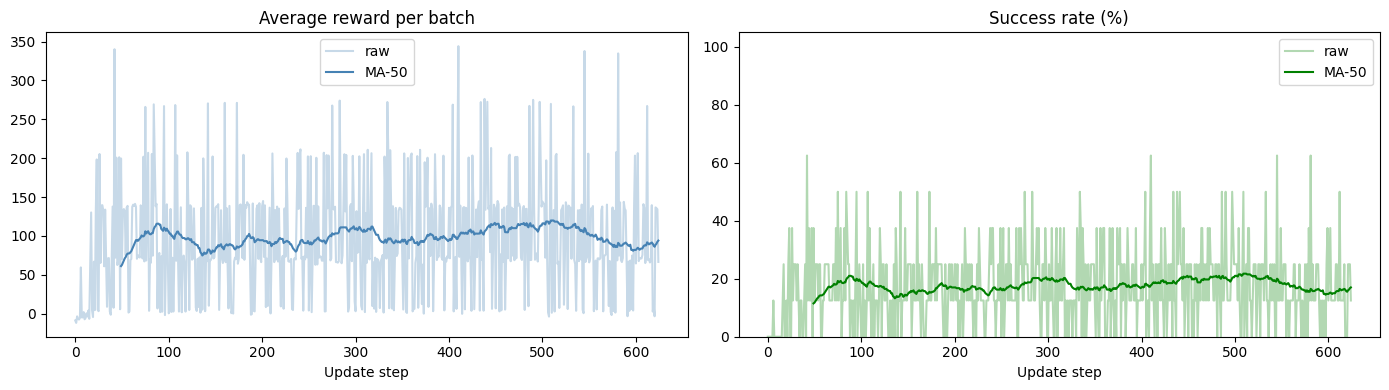

Saved training_curve_v3_16x16_fullmap.png


In [ ]:
try:
    import matplotlib.pyplot as plt

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    rewards = checkpoint["rewards_hist"]
    window  = 50
    smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')
    ax1.plot(rewards, alpha=0.3, color='steelblue', label='raw')
    ax1.plot(range(window-1, len(rewards)), smoothed, color='steelblue', label=f'MA-{window}')
    ax1.set_title('Average reward per batch')
    ax1.set_xlabel('Update step')
    ax1.legend()

    success = [s * 100 for s in checkpoint["success_hist"]]
    s_smooth = np.convolve(success, np.ones(window)/window, mode='valid')
    ax2.plot(success, alpha=0.3, color='green', label='raw')
    ax2.plot(range(window-1, len(success)), s_smooth, color='green', label=f'MA-{window}')
    ax2.set_title('Success rate (%)')
    ax2.set_xlabel('Update step')
    ax2.set_ylim(0, 105)
    ax2.legend()

    plt.tight_layout()
    plt.savefig('training_curve_v3_16x16_fullmap.png', dpi=150)
    plt.show()
    print('Saved training_curve_v3_16x16_fullmap.png')
except ImportError:
    print('matplotlib not available — skipping plot')
